In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import numpy as np
import kagglehub
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm
import os
import glob
import cv2
from PIL import Image
import pandas as pd
from torchmetrics import JaccardIndex
from datasets import load_dataset
from IPython.display import display
from torch.optim.lr_scheduler import CyclicLR, OneCycleLR, CosineAnnealingWarmRestarts, LinearLR
from torchsummary import summary

import matplotlib.pyplot as plt
import numpy as np
import torch
import random
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics import JaccardIndex

 
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import json
from helperFunctions import HelperFunctions

/home/adminnio/miniconda3/envs/navigator/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 42
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True #False
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)
gpu_name = torch.cuda.get_device_name(device)
print(f"GPU Name: {gpu_name}")

Using device cuda:0
GPU Name: NVIDIA GeForce RTX 4090


In [3]:
path = '/media/adminnio/Volume/Data_NerfRaw/Lakshwadeep/LAK/1/colmap'
poses, c2w = HelperFunctions.get_camera_poses(path)
#HelperFunctions.plot_camera_poses(poses)
with open((rf"{path}/transforms.json"), "r") as file:
    data = json.load(file)
    

In [4]:
W, H ,focalLength = data.get("w"), data.get("h"), data.get("fl_x")
W = 50 #Fixed for Testing 
H = 50 #Fixed for Testing should generate 50*50=2500 points
origins = poses[:,:-3]
camera_vector = poses[1,3:]

In [5]:
originrays, dirrays  = HelperFunctions.generateRays(1, 10, origins[3], H, W, focalLength,c2w[1])
#Takes in near bound, farbound,origin cord, image dims, Focal Length, transformation matrix. generate rays for each origin
#originrays shape is [NRays ,3] tensor, all same values
# dirrays is also [NRays ,3] tensor
pts = HelperFunctions.samplePoints(originrays, dirrays, numPoints=20, tn=1, tf=20)
#sample 20 points over each ray, returns cordinates [20,3] for each ray * NRays tensor

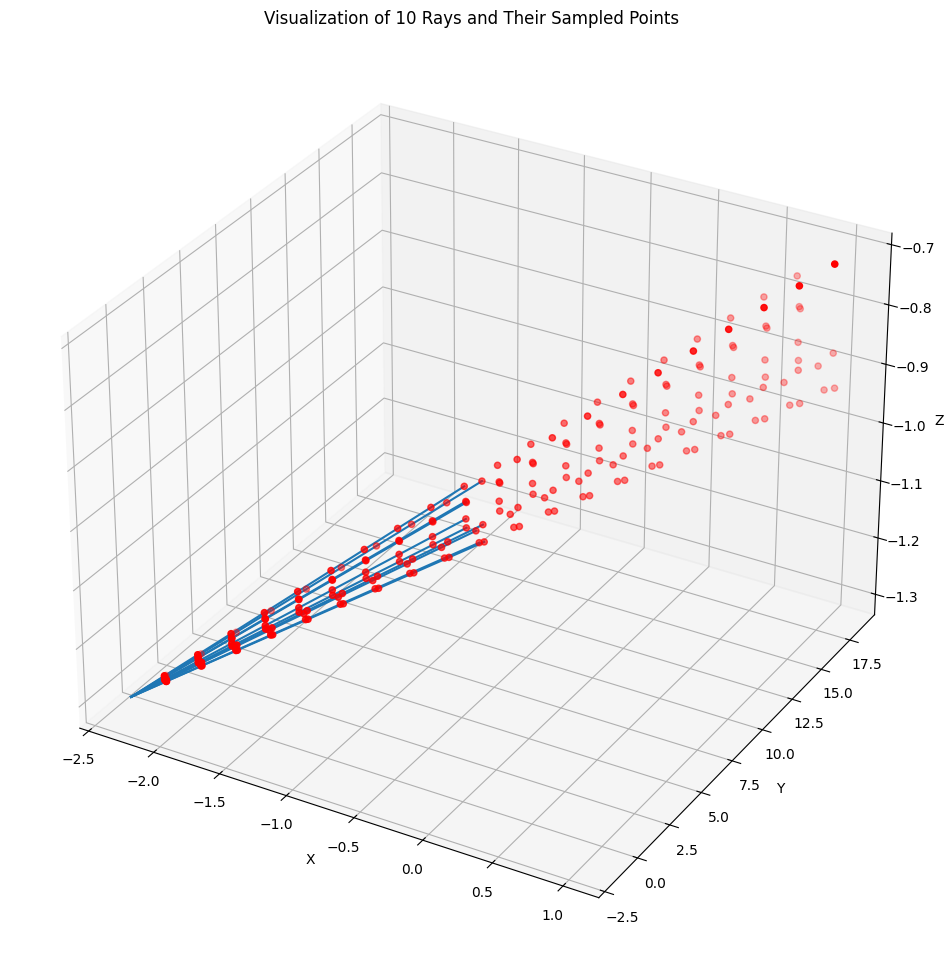

In [6]:
#HelperFunctions.plot_rays(originrays, dirrays,10,10)
#HelperFunctions.plot_ray(pts, 2)
HelperFunctions.plot_rays_and_points(originrays, dirrays, pts)

In [7]:
HelperFunctions.stratifiedSampling()

TypeError: HelperFunctions.stratifiedSampling() missing 5 required positional arguments: 'o', 'd', 'numPoints', 'tn', and 'tf'